# Notebook 8 — Evaluation Results & Cross-Model Comparison

## Evaluation Setup

This section prepares the environment for comparative evaluation across all models. Required libraries for analysis and visualisation are loaded, and paths to stored results and predictions are configured.

A consistent visual style and colour mapping are defined to ensure uniformity across evaluation plots.

In [1]:
# Path setup for project imports
import sys, os, pickle
sys.path.insert(0, os.path.abspath('..'))

# Core libraries for data handling and visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Evaluation metrics for curves
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Import configuration
from config import (
    VISUALISATION_DIR,
    CSV_DIR,
    BASELINE_RESULTS_CSV,
    ROBERTA_RESULTS_CSV,
    ROBERTA_PREDS_PKL,
    TWITTERROBERTA_RESULTS_CSV,
    TWITTERROBERTA_PREDS_PKL,
    DISTILROBERTA_RESULTS_CSV,
    DISTILROBERTA_PREDS_PKL,
    ALL_RESULTS_CSV,
)

# Output directory for evaluation plots
EVAL_DIR = VISUALISATION_DIR / 'evaluation'
os.makedirs(EVAL_DIR, exist_ok=True)

# Global plotting configuration
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': ':',
})

# Consistent colour mapping for models
MODEL_COLORS = {
    'RoBERTa': '#C1121F',
    'TwitterRoBERTa': '#0077B6',
    'DistilRoBERTa': '#2A9D8F',
}

## Loading Evaluation Results and Predictions

This step loads all saved evaluation results and prediction outputs for baseline and transformer models.

The result tables contain performance metrics such as Accuracy, Precision, Recall, F1-score, and ROC-AUC for each experiment configuration. Prediction files are also loaded to support downstream analyses such as ROC curves, precision–recall curves, and error analysis.

A helper function is used to load serialized prediction files, ensuring consistent and reusable loading logic.

Finally, the results for each model family are printed in a structured format, enabling quick inspection and comparison of performance across baseline and transformer models.

In [2]:
# Load result tables
baseline_df = pd.read_csv(BASELINE_RESULTS_CSV)
roberta_df = pd.read_csv(ROBERTA_RESULTS_CSV)
twitterroberta_df = pd.read_csv(TWITTERROBERTA_RESULTS_CSV)
distilroberta_df = pd.read_csv(DISTILROBERTA_RESULTS_CSV)

# Helper to load prediction files
def load_pkl(path: str) -> dict:
    with open(path, 'rb') as f:
        return pickle.load(f)

# Load prediction outputs
rob_preds = load_pkl(ROBERTA_PREDS_PKL)
tw_preds  = load_pkl(TWITTERROBERTA_PREDS_PKL)
dis_preds = load_pkl(DISTILROBERTA_PREDS_PKL)

# Display results
print('\nBaseline:')
print(
    baseline_df[
        ['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    ].round(4).to_string(index=False)
)

print('\nRoBERTa:')
print(
    roberta_df.round(4).to_string(index=False)
)

print('\nTwitterRoBERTa:')
print(
    twitterroberta_df.round(4).to_string(index=False)
)

print('\nDistilRoBERTa:')
print(
    distilroberta_df.round(4).to_string(index=False)
)


Baseline:
              model  accuracy  precision  recall     f1  roc_auc
Logistic Regression    0.9171     0.9309  0.9011 0.9158   0.9725
         Linear SVM    0.9244     0.9302  0.9178 0.9240   0.9764
      Random Forest    0.8799     0.8907  0.8663 0.8783   0.9423

RoBERTa:
                      Experiment  Accuracy  Precision  Recall     F1  ROC-AUC
                RoBERTa Baseline    0.9826     0.9892  0.9759 0.9825   0.9975
              RoBERTa + Negation    0.9806     0.9787  0.9826 0.9807   0.9977
RoBERTa + Negation + Intensifier    0.9803     0.9865  0.9739 0.9802   0.9969

TwitterRoBERTa:
                             Experiment  Accuracy  Precision  Recall     F1  ROC-AUC
                TwitterRoBERTa Baseline    0.9843     0.9892  0.9793 0.9842   0.9986
              TwitterRoBERTa + Negation    0.9819     0.9865  0.9773 0.9819   0.9982
TwitterRoBERTa + Negation + Intensifier    0.9860     0.9866  0.9853 0.9860   0.9983

DistilRoBERTa:
                            Experi

## Best Configuration per Transformer Family

This step identifies the best-performing configuration for each transformer model family based on the highest F1 score.

For each model (RoBERTa, TwitterRoBERTa, and DistilRoBERTa), the row corresponding to the maximum F1 score is selected. This ensures that comparisons across models are made using their optimal settings rather than arbitrary configurations.

The resulting table summarises key evaluation metrics including Accuracy, Precision, Recall, F1, and ROC-AUC for the best configuration of each model. This provides a concise and fair comparison of peak model performance across transformer architectures.

In [3]:
# Helper to extract best-performing row based on F1
def best_row(df: pd.DataFrame, family: str) -> pd.Series:
    f1_col = next(c for c in df.columns if c.lower() == 'f1')
    row    = df.loc[df[f1_col].idxmax()].copy()
    row['Family'] = family
    return row

# Select best configuration per model family
transformer_best = pd.DataFrame([
    best_row(roberta_df,        'RoBERTa'),
    best_row(twitterroberta_df, 'TwitterRoBERTa'),
    best_row(distilroberta_df,  'DistilRoBERTa'),
])

# Display results
print('Best condition per model family:')
display_cols = [
    c for c in [
        'Family',
        'Experiment',
        'Accuracy',
        'Precision',
        'Recall',
        'F1',
        'ROC-AUC'
    ]
    if c in transformer_best.columns
]

print(
    transformer_best[display_cols]
    .round(4)
    .to_string(index=False)
)


Best condition per model family:
        Family                              Experiment  Accuracy  Precision  Recall     F1  ROC-AUC
       RoBERTa                        RoBERTa Baseline    0.9826     0.9892  0.9759 0.9825   0.9975
TwitterRoBERTa TwitterRoBERTa + Negation + Intensifier    0.9860     0.9866  0.9853 0.9860   0.9983
 DistilRoBERTa                  DistilRoBERTa Baseline    0.9779     0.9754  0.9806 0.9780   0.9973


## ROC Curve Analysis

This plot presents the Receiver Operating Characteristic (ROC) curves for all transformer models on the test set.

The ROC curve illustrates the trade-off between the **True Positive Rate (Recall)** and the **False Positive Rate** across different classification thresholds. It provides a comprehensive view of a model’s ability to distinguish between classes.

The **Area Under the Curve (AUC)** is used as a summary metric:
- AUC = 1.0 indicates perfect classification  
- AUC = 0.5 corresponds to random guessing  

A dashed diagonal line represents the random baseline for reference.

Comparing ROC curves helps evaluate how well each transformer model separates positive and negative classes, especially in terms of ranking quality across thresholds.

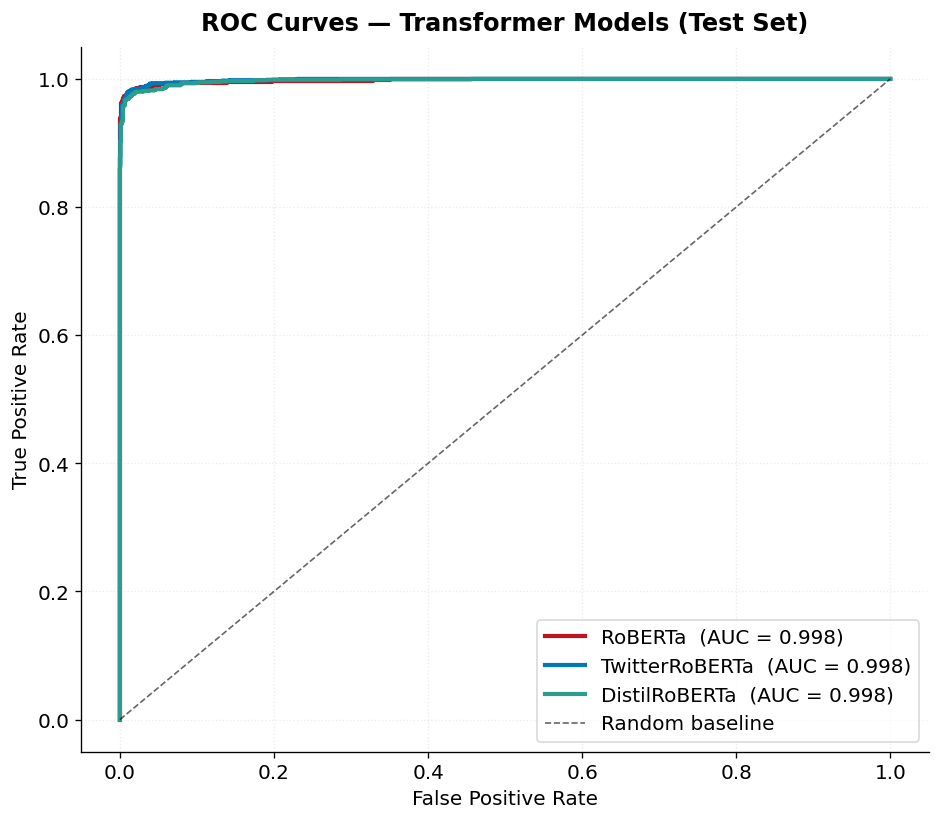

In [4]:
# Plot ROC curves for transformer models
fig, ax = plt.subplots(figsize=(8, 7))

for name, preds in [
    ('RoBERTa', rob_preds),
    ('TwitterRoBERTa', tw_preds),
    ('DistilRoBERTa', dis_preds)
]:
    if not preds.get('test_labels'):
        continue

    fpr, tpr, _ = roc_curve(
        preds['test_labels'],
        preds['test_probs']
    )

    roc_auc = auc(fpr, tpr)

    ax.plot(
        fpr,
        tpr,
        label=f'{name}  (AUC = {roc_auc:.3f})',
        color=MODEL_COLORS[name],
        linewidth=2.5
    )

# Random baseline
ax.plot(
    [0, 1],
    [0, 1],
    'k--',
    linewidth=1,
    alpha=0.6,
    label='Random baseline'
)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')

ax.set_title(
    'ROC Curves — Transformer Models (Test Set)',
    fontweight='bold',
    pad=10
)

ax.legend(loc='lower right', framealpha=0.75)
plt.tight_layout()

plt.savefig(
    EVAL_DIR / 'roc_curves.png',
    bbox_inches='tight'
)
plt.show()

## Precision–Recall Curve Analysis

This plot visualises the Precision–Recall (PR) curves for all transformer models on the test set.

Precision–Recall curves are particularly useful for imbalanced classification problems, as they focus on the trade-off between **precision** (how many predicted positives are correct) and **recall** (how many actual positives are captured).

Each curve represents a model’s performance across different classification thresholds. The **Average Precision (AP)** score summarises the overall quality of the curve, with higher values indicating better performance.

Comparing these curves allows us to assess which transformer model maintains high precision at higher recall levels, providing a more nuanced evaluation than accuracy alone.

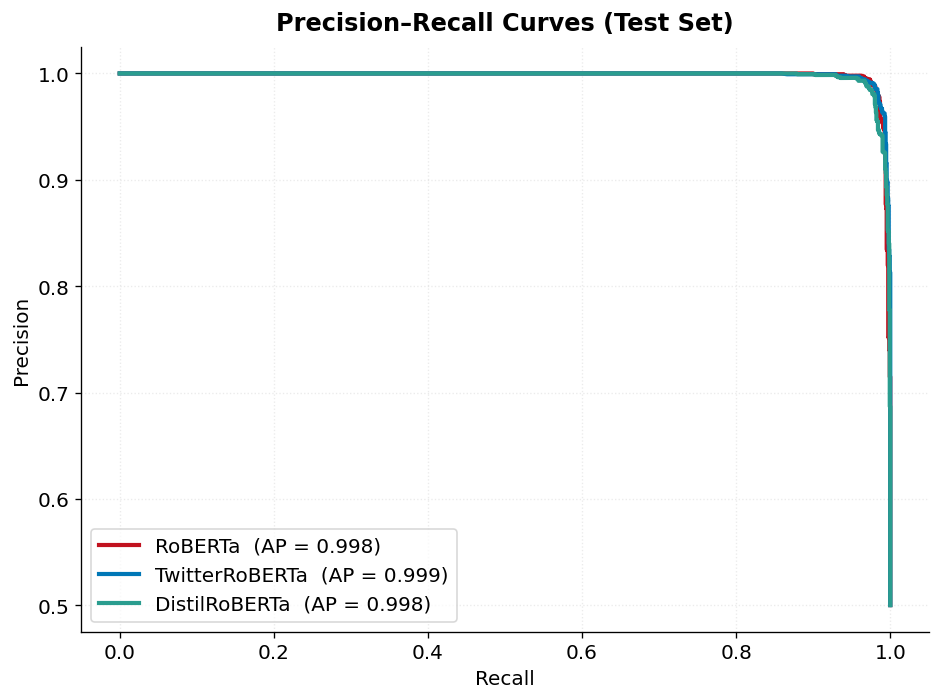

In [5]:
# Plot Precision–Recall curves for transformer models
fig, ax = plt.subplots(figsize=(8, 6))

for name, preds in [
    ('RoBERTa', rob_preds),
    ('TwitterRoBERTa', tw_preds),
    ('DistilRoBERTa', dis_preds)
]:
    if not preds.get('test_labels'):
        continue

    prec, rec, _ = precision_recall_curve(
        preds['test_labels'],
        preds['test_probs']
    )

    ap = average_precision_score(
        preds['test_labels'],
        preds['test_probs']
    )

    ax.plot(
        rec,
        prec,
        label=f'{name}  (AP = {ap:.3f})',
        color=MODEL_COLORS[name],
        linewidth=2.5
    )

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title(
    'Precision–Recall Curves (Test Set)',
    fontweight='bold',
    pad=10
)

ax.legend(framealpha=0.75)
plt.tight_layout()

plt.savefig(
    EVAL_DIR / 'pr_curves.png',
    bbox_inches='tight'
)
plt.show()

## Ablation Impact on F1 Score

This section compares the effect of incremental feature additions on model performance using an ablation study. For each transformer variant, the change in F1 score is measured relative to its baseline configuration.

The bars show how performance shifts after adding negation features and then both negation and intensifier features. Positive values indicate improvement over the baseline, while negative values indicate performance degradation. This representation makes it easier to assess whether each added feature contributes meaningful predictive value.

By comparing RoBERTa, TwitterRoBERTa, and DistilRoBERTa side by side, the plot highlights how different architectures respond to the same feature augmentations. This helps identify which models benefit most from linguistic signal injection and whether the added features consistently improve classification performance.

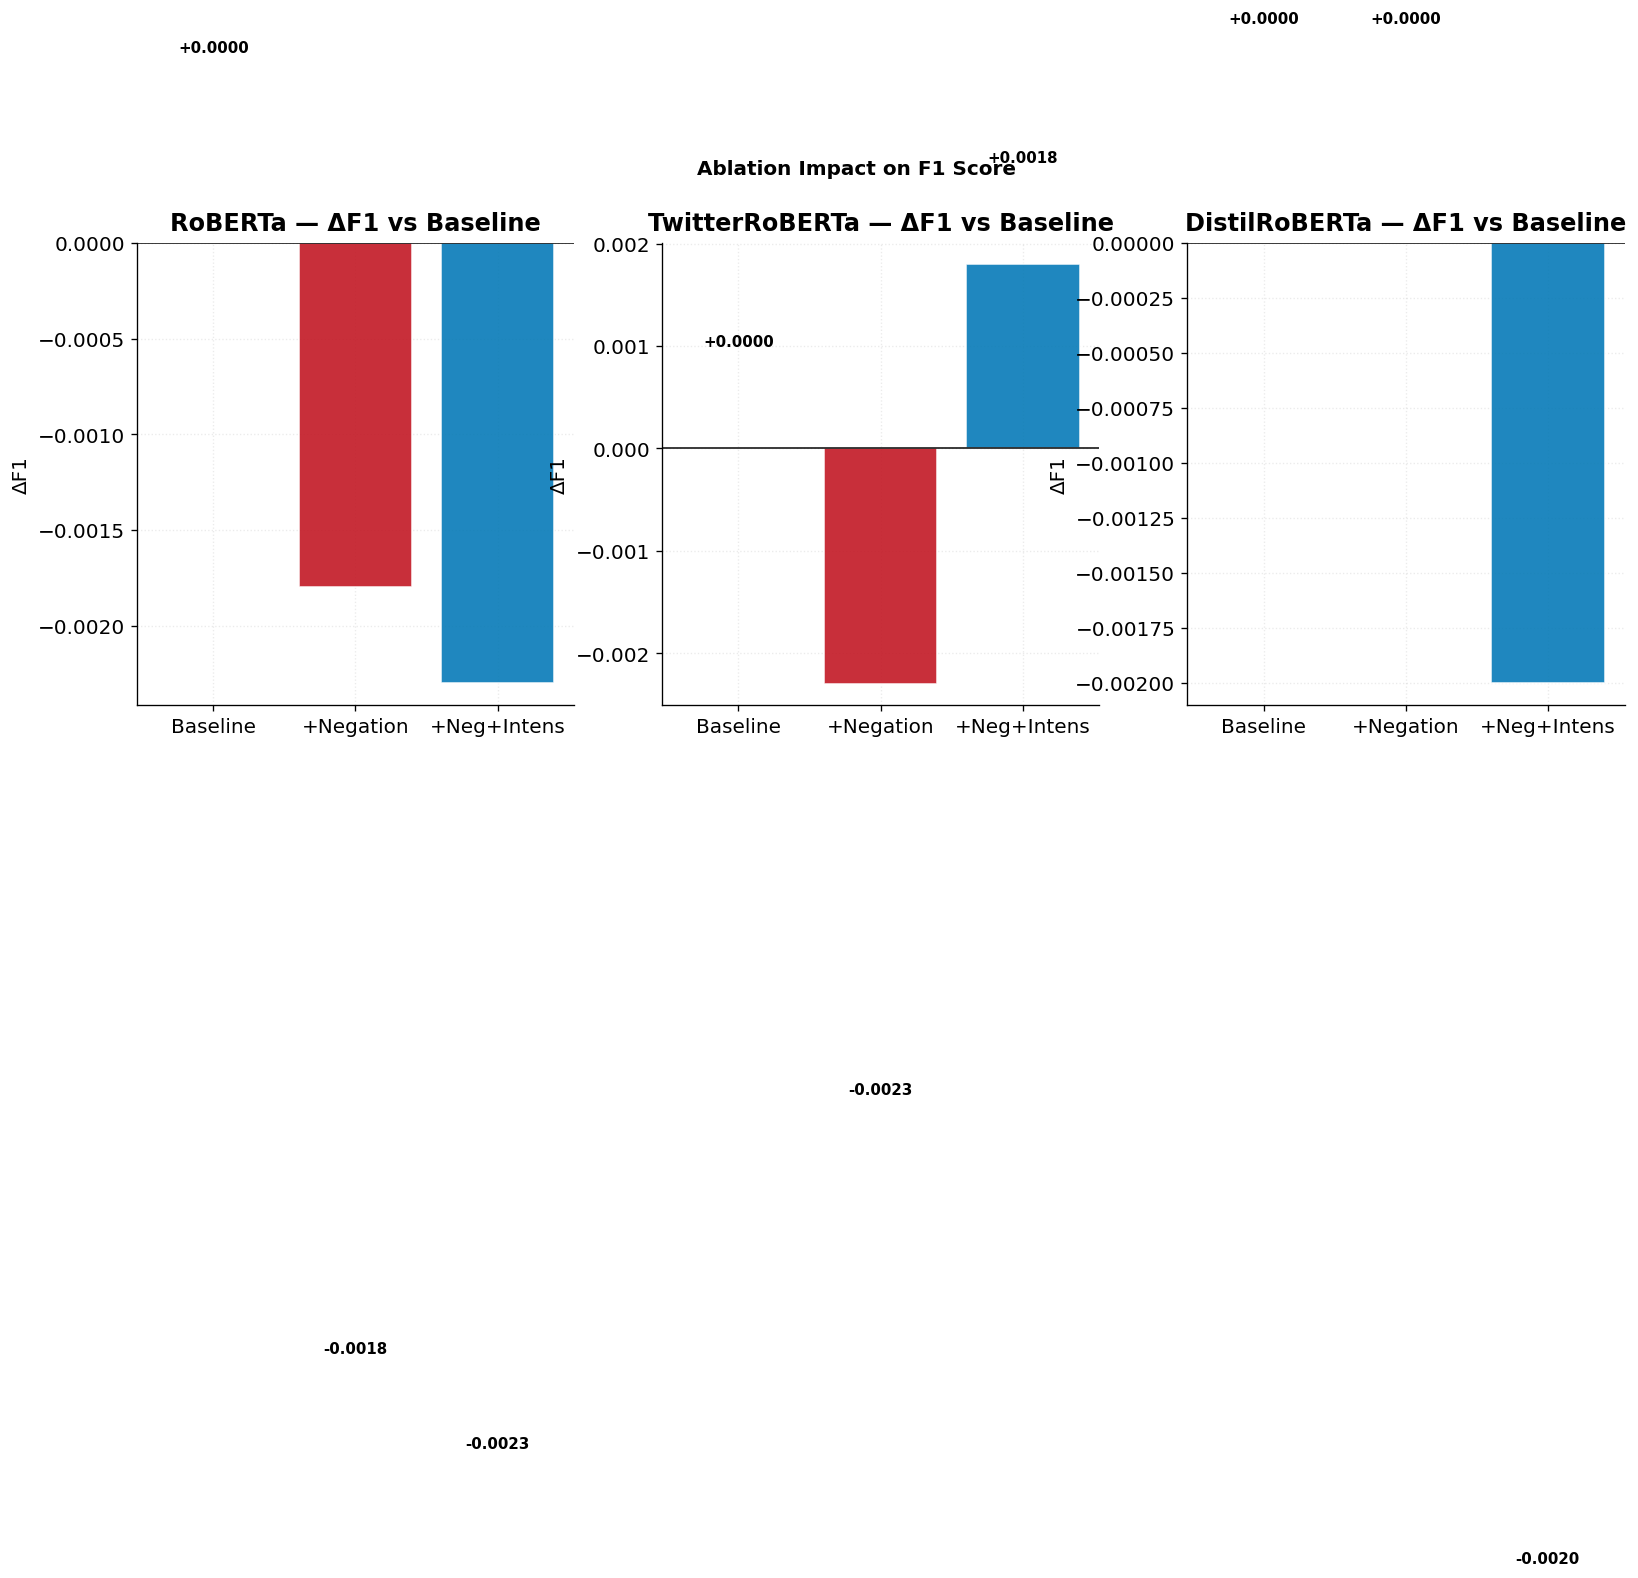

In [6]:
# Ablation Impact on F1 Score
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
bar_colors = ['#ADB5BD', '#C1121F', '#0077B6']
x_labels = ['Baseline', '+Negation', '+Neg+Intens']

for ax, df_ab, title in zip(
    axes,
    [roberta_df, twitterroberta_df, distilroberta_df],
    ['RoBERTa', 'TwitterRoBERTa', 'DistilRoBERTa'],
):
    f1_col = next(c for c in df_ab.columns if c.lower() == 'f1')
    deltas = df_ab[f1_col].values - df_ab[f1_col].values[0]
    labels = x_labels[:len(deltas)]

    bars = ax.bar(
        labels,
        deltas,
        color=bar_colors[:len(deltas)],
        edgecolor='white',
        alpha=0.88
    )

    ax.axhline(0, color='black', linewidth=0.9)

    for bar, v in zip(bars, deltas):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (0.001 if v >= 0 else -0.004),
            f'{v:+.4f}',
            ha='center',
            fontsize=9,
            fontweight='bold'
        )

    ax.set_title(f'{title} — ΔF1 vs Baseline', fontweight='bold', pad=8)
    ax.set_ylabel('ΔF1')
    ax.set_axisbelow(True)

plt.suptitle('Ablation Impact on F1 Score', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(EVAL_DIR / 'ablation_delta_f1.png', bbox_inches='tight')
plt.show()

## Consolidating Model Results

This step combines the evaluation results from all model families into a single unified dataset. Each model group (Baseline, RoBERTa, TwitterRoBERTa, and DistilRoBERTa) is tagged with a `family` label to enable grouped analysis and comparison.

The individual result DataFrames are concatenated into one comprehensive table, ensuring consistent structure across all experiments. This consolidated dataset simplifies downstream analysis, such as plotting performance comparisons, statistical summaries, or exporting results for reporting.

Finally, the combined results are saved as a CSV file, serving as a central record of all experimental outcomes.

In [7]:
# Add model family labels
baseline_df['family'] = 'Baseline'
roberta_df['family'] = 'RoBERTa'
twitterroberta_df['family'] = 'TwitterRoBERTa'
distilroberta_df['family'] = 'DistilRoBERTa'

# Combine all results into a single DataFrame
combined = pd.concat(
    [baseline_df, roberta_df, twitterroberta_df, distilroberta_df],
    ignore_index=True
)

# Save combined results
combined.to_csv(ALL_RESULTS_CSV, index=False)